# Caterpillar Benchmark Analysis (RT Evaluation)

## Overview

This Jupyter Notebook performs an analytical evaluation of **Caterpillar Benchmark for Real-Time (RT)** test results.  
The Caterpillar benchmark measures how deterministically a system responds under load — specifically focusing on **timing jitter**, **CPU thermal conditions**, and **interrupt activity**.  

The notebook analyzes output data, fits a **Generalized Extreme Value (GEV)** distribution to **Session Jitter**, and examines correlations with CPU temperature and IRQ activity to identify potential sources of non-determinism.

---

## What Is the Caterpillar Benchmark for RT?

The **Caterpillar RT Benchmark** is a diagnostic tool designed to:
- Evaluate **real-time responsiveness** of CPU cores under varying system conditions.
- Measure **timing jitter** (variations in scheduling and latency).
- Identify hardware or kernel-level contributors to timing instability (e.g., IRQs, temperature fluctuations).

The benchmark runs multiple real-time workloads while collecting detailed monitoring data from the system.

---

## Input Data Description

The benchmark generates several monitoring files in the **output directory**, each containing time-synchronized measurements from different subsystems.

| File | Description |
|------|--------------|
| `output.csv` | Primary timing dataset (sample and session jitter metrics). |
| `cpu_monitor.csv` | CPU temperature, frequency, and utilization per core. |
| `cpustat_monitor.csv` | Detailed CPU statistics (user/system/idle times, context switches). |
| `irq_monitor.csv` | IRQ activity counts per CPU core over time. |
| `softirq_monitor.csv` | Kernel-level soft interrupt counts per CPU core. |
| `meminfo_monitor.csv` | Memory pressure and allocation statistics. |
| `sysinfo.json` | System configuration and metadata (CPU topology, kernel version, etc.). |

---

## Structure of `output.csv`

The file `output.csv` contains per-sample jitter measurements recorded during the benchmark.  
Each row represents a single sampling point with both **sample-level** and **session-level** timing information.

| Column | Description | Units |
|---------|--------------|-------|
| `timestamp` | Timestamp of the measurement | ISO 8601 datetime |
| `SampleMin` | Minimum latency within current sampling window | microseconds (µs) |
| `SampleMax` | Maximum latency within current sampling window | microseconds (µs) |
| `SmplJitter` | Difference between `SampleMax` and `SampleMin` (per-sample jitter) | microseconds (µs) |
| `SessionMin` | Minimum latency observed since session start | microseconds (µs) |
| `SessionMax` | Maximum latency observed since session start | microseconds (µs) |
| `SessionJitter` | `SessionMax - SessionMin`, cumulative jitter for the session | microseconds (µs) |
| `Sample` | Sequential sample index | integer |


## How can I run analysis? 

You need to specify **folder** path in the next cell and run cells below, you will get report automatically then

In [1]:
caterpillar_data_path = "../data/05-19-35"

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme, genpareto
from statsmodels.tsa.stattools import adfuller
import seaborn as sns 
import sys
import os 
import yaml
import json

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.plots import *


output_csv_path = f"{caterpillar_data_path}/output.csv"
cpu_monitor_path = f"{caterpillar_data_path}/cpu_monitor.csv"
irq_monitor_path = f"{caterpillar_data_path}/irq_monitor.csv"
meminfo_path = f"{caterpillar_data_path}/meminfo_monitor.csv"
hydra_conf_path = f"{caterpillar_data_path}/.hydra/config.yaml"
sysinfo_path = f"{caterpillar_data_path}/sysinfo.json"

In [64]:
with open(hydra_conf_path, 'r') as stream:
    hydra_conf = yaml.safe_load(stream)

with open(sysinfo_path) as f:
    sysinfo = json.load(f)

In [21]:
assert hydra_conf['run']['command'] == 'caterpillar', "This notebook is designed to analyze caterpillar!"

In [63]:
print(f"""
Analyzing {hydra_conf['run']['command']}
With isolated core(s): {hydra_conf['run']['t_core']}
Cache mask: {hydra_conf['run']['llc_cache_mask']}
System is stessed?: {hydra_conf['run']['stressor']}
Kernel: {sysinfo['kernel']['uname']}
Kernel CMD: {sysinfo['kernel']['cmdline']}
""")


Analyzing caterpillar
With isolated core(s): 3
Cache mask: 0x7ff0
System is stessed?: True
Kernel: Linux zededa-rt 6.12.8-intel-ese-experimental-lts-rt #1 SMP PREEMPT_RT Thu, 28 Aug 2025 10:46:22 +0000 x86_64 GNU/Linux
Kernel CMD: BOOT_IMAGE=/vmlinuz-6.12.8-intel-ese-experimental-lts-rt root=/dev/mapper/zededa--rt--vg-root ro BOOT_IMAGE=/vmlinuz-6.12.8-intel-ese-experimental-lts-rt root=/dev/mapper/zededa--rt--vg-root ro debug=all nosplash console=ttyS0,115200 console=tty0 clocksource=tsc tsc=reliable art=virtallow no_ipi_broadcast=1 nosoftlockup efi=runtime numa_balancing=disable hugepages=1024 audit=0 nmi_watchdog=0 irqaffinity=0,1 mce=off hpet=disable rcupdate.rcu_cpu_stall_suppress=1 rcu_nocb_poll noht isolcpus=3,5,7,9 rcu_nocbs=3,5,7,9 nohz_full=3,5,7,9 intel_pstate=disable intel.max_cstate=0 intel_idle.max_cstate=0 processor.max_cstate=0 processor_idle.max_cstate=0 i915.force_probe=* i915.enable_rc6=0 i915.enable_dc=0 i915.disable_power_well=0 igb.blacklist=no console=ttyS0,1152

### TL;DR checking if caterpillar jitter is limited

We are fitting General Extreme Value distribution (GEV) into SessionJitter data, to predict what would be in 99.999% cases **maximal** value of SessionJitter. one can derrive mean and std from that distribution, however we focus on 99.999% quantile

**Things to check**:

- 99.999% quantile to see maximal value
- Graph for return level should be limited from top

**Important**

- GEV talks about guarantee over the period observed
- External conditions might affect performance (i.e. CPU temperature)

**Example of bad(unstable) distribution**

```
Analyzing 7000 data points from column 'SessionJitter'.
------------------------------
GEV Fit Parameters:
  Shape (c):   -6.4028
  Location (loc): 34280.4348
  Scale (scale): 2.7837
------------------------------
Return Value at 99.9999% quantile: 113556574254277904332450940195107241984.00 CPU cycles
```


<img src="imgs/00_bad_SessionJitter.png">

<img src="imgs/00_bad_return_level.png"> 



Analyzing 12000 data points from column 'SessionJitter'.
------------------------------
GEV Fit Parameters:
  Shape (c):   0.9382
  Location (loc): 24764.7886
  Scale (scale): 3201.2782
------------------------------
Return Value at 99.9999% quantile: 28177.06 CPU cycles
------------------------------


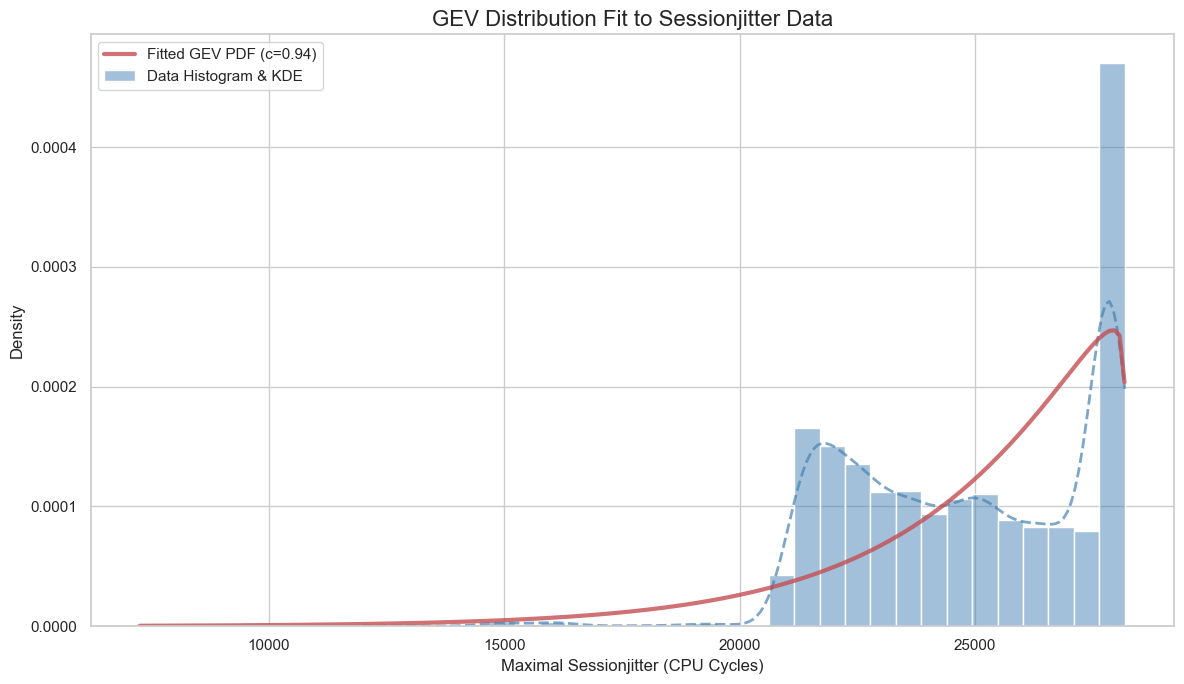

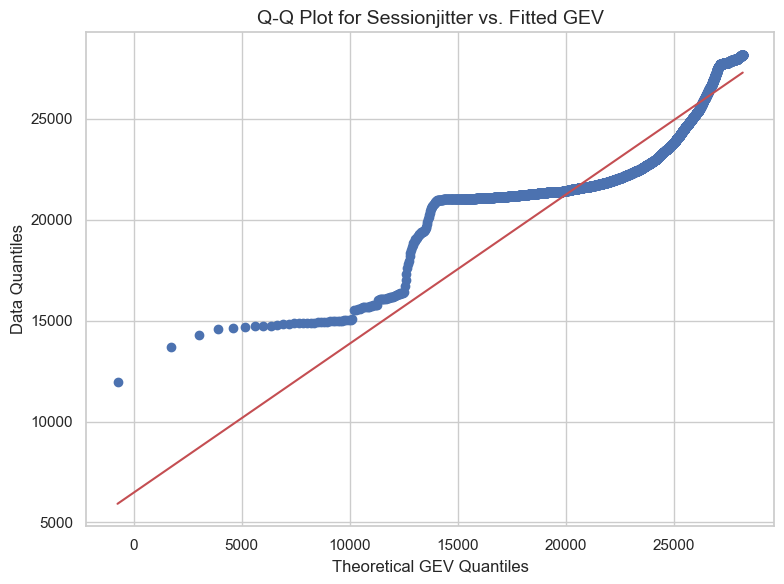

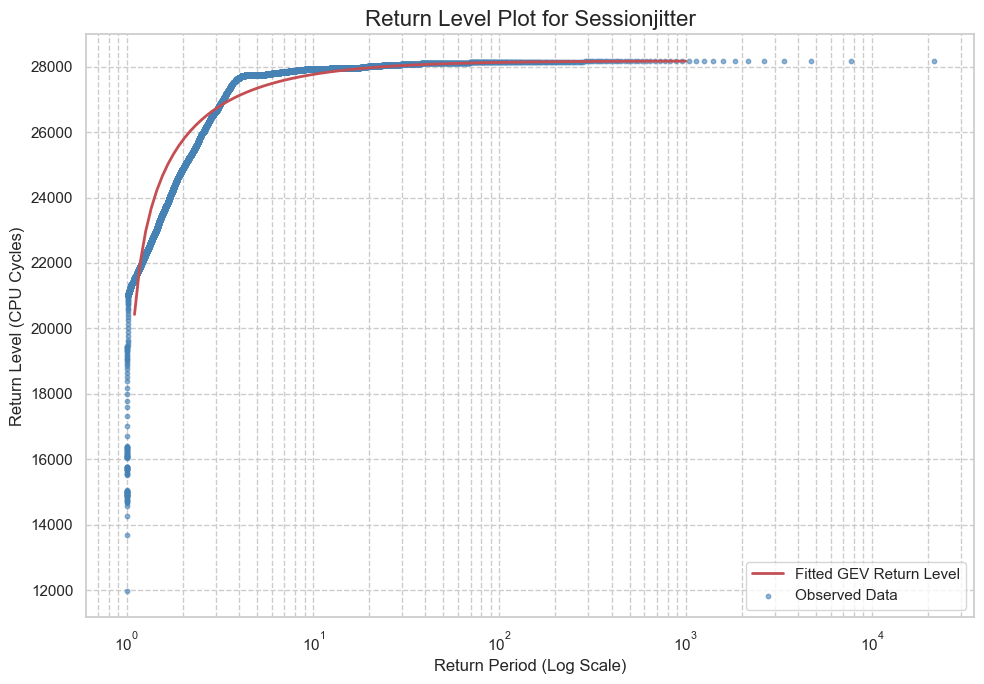

In [27]:
df = pd.read_csv(output_csv_path)
fit_and_plot_gev(df, "SessionJitter")

### Bonus check :see line graph of jitter to see how it behaves over time

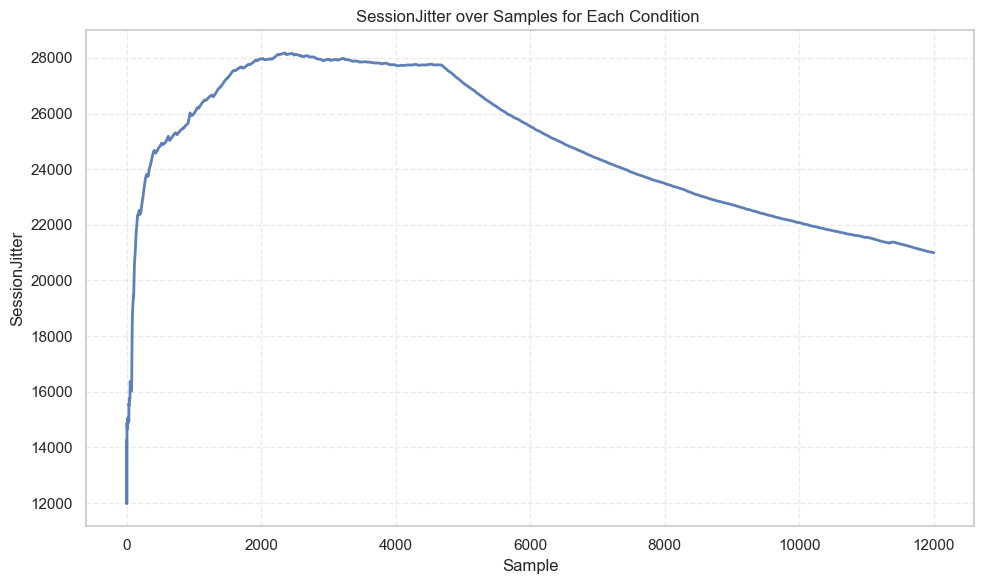

In [29]:
lineplot(df, x_col="Sample", y_col="SessionJitter", tag="")

### Sanity check #0: environment configuration check

In [70]:
from typing import Sequence, Tuple
import re

def parse_kernel_cmdline(cmdline: str, params: Sequence[str]) -> dict[str, str]:
    results = {}

    for param in params:
        # Find all matches like param=value
        matches = re.findall(rf'\b{param}=([^ ]+)', cmdline)

        if not matches:
            print(f"{param}: not found")
            results[param] = None
        elif len(matches) == 1:
            print(f"{param}: {matches[0]}")
            results[param] = matches[0]
        else:
            print(f"WARNING: multiple occurrences of '{param}' found! Using latest value.")

            
            for value in matches:
                print(f"  -> {param}={value}")
            latest = matches[-1]
            print(f"Using latest: {param}={latest}")
            results[param] = latest

    return results

In [75]:
# check 1: selected for tests CPUs are isolated

params = parse_kernel_cmdline(sysinfo['kernel']['cmdline'], ["rcu_nocbs", "nohz_full", "isolcpus"])

for cpu in hydra_conf['run']['t_core'].split(','):
    for k, v in params.items():
        assert cpu in v, f"{k} parameter of kernel cmdline is missing CPU {cpu} which is used in tests"

  -> rcu_nocbs=3,5,7,9
  -> rcu_nocbs=1,3
Using latest: rcu_nocbs=1,3
  -> nohz_full=3,5,7,9
  -> nohz_full=1,3
Using latest: nohz_full=1,3
  -> isolcpus=3,5,7,9
  -> isolcpus=1,3
Using latest: isolcpus=1,3


In [78]:
# check 2 p-state and c-state are disabled

params = parse_kernel_cmdline(sysinfo['kernel']['cmdline'], ["intel_pstate", "intel.max_cstate", "intel_idle.max_cstate", "processor.max_cstate", "processor_idle.max_cstate"])

assert params["intel_pstate"] == "disable", "Intel p-state must be disabled"
assert params["intel.max_cstate"] == "0", "Intel c-state must be disabled"
assert params["intel_idle.max_cstate"] == "0", "Intel c-state must be disabled"
assert params["processor.max_cstate"] == "0", "Intel c-state must be disabled"
assert params["processor_idle.max_cstate"] == "0", "Intel c-state must be disabled"

  -> intel_pstate=disable
  -> intel_pstate=disable
Using latest: intel_pstate=disable
  -> intel.max_cstate=0
  -> intel.max_cstate=0
Using latest: intel.max_cstate=0
  -> intel_idle.max_cstate=0
  -> intel_idle.max_cstate=0
Using latest: intel_idle.max_cstate=0
  -> processor.max_cstate=0
  -> processor.max_cstate=0
Using latest: processor.max_cstate=0
  -> processor_idle.max_cstate=0
  -> processor_idle.max_cstate=0
Using latest: processor_idle.max_cstate=0


In [79]:
# check 3: hypter-threading is disabled

assert " noht " in sysinfo['kernel']['cmdline']

### Sanity check #1: CPU temperature is not exceeding Threshold

If CPU is overheated termal throttling could be used, which would strongly affect performance. Below threshold is defined

In [32]:
heat_threshold = 90

In [37]:
### Check 1: Packages do not exceed threshold

packages = [col for col in cpu_monitor_df.columns if col.startswith("Package id")]

for pkg in packages:
    assert cpu_monitor_df[pkg].max() <= heat_threshold

In [38]:
### Check 2: CPUs do not exceed threshold

cpus = [col for col in cpu_monitor_df.columns if col.startswith("CPU")]

for cpu in cpus:
    assert cpu_monitor_df[cpu].max() <= heat_threshold

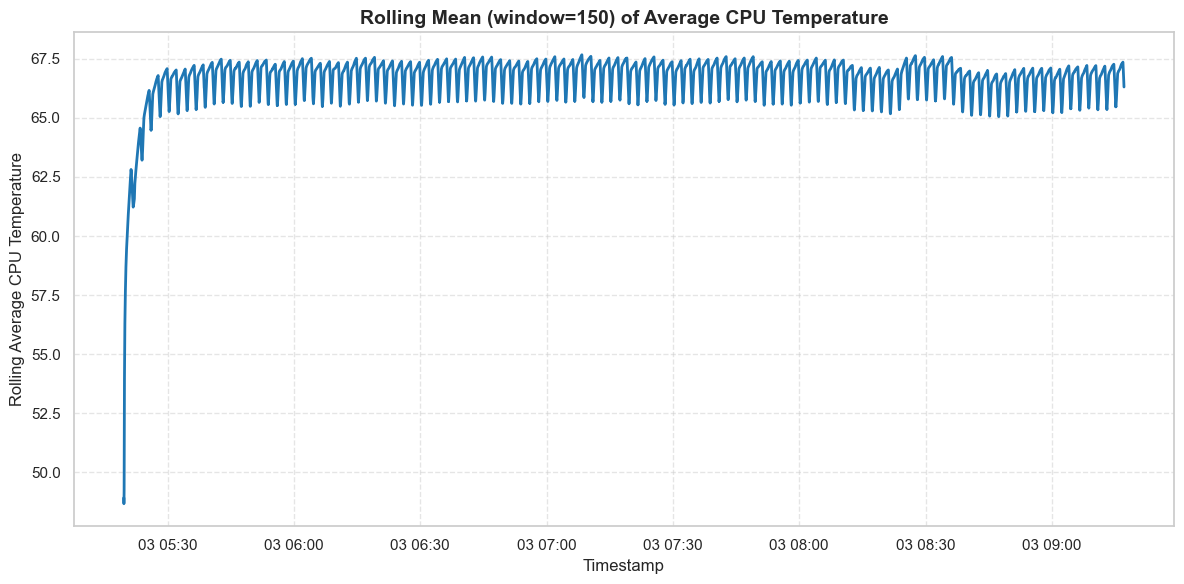

In [39]:
### Check 3: plot average temperature

cpu_monitor_df = pd.read_csv(cpu_monitor_path)
plot_avg_cpu_temp(cpu_monitor_df)

### Sanity check #2: No global IRQs are happening on CPUs that are being tested

In [48]:
irq_monitor_df = pd.read_csv(irq_monitor_path)
mask = irq_monitor_df['description'].str.contains('APIC|MSIX', case=False, regex=True, na=False)
global_irqs = irq_monitor_df[mask]

for cpu in hydra_conf['run']['t_core'].split(','):
    assert global_irqs[f'CPU{cpu}'].sum() == 0

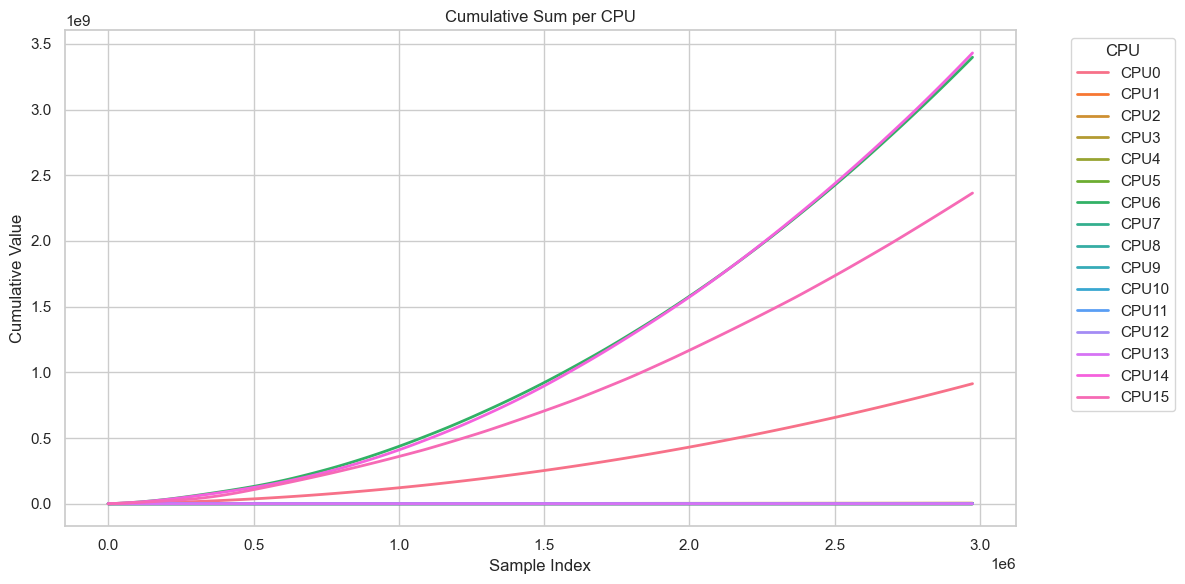

In [51]:
## Bonus check: plot cumsum of CPU interrupts for each CPU

cpu_cols = [col for col in irq_monitor_df.columns if col.startswith('CPU')]
cpu_df = global_irqs[cpu_cols]
cpu_cumsum_df = cpu_df.cumsum()

cpu_long_df = cpu_cumsum_df.reset_index().melt(id_vars='index', var_name='CPU', value_name='Cumulative Value')

# Plot with seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(data=cpu_long_df, x='index', y='Cumulative Value', hue='CPU', linewidth=2)

plt.title('Cumulative Sum of system interrruptions per CPU')
plt.xlabel('Sample Index')
plt.ylabel('Cumulative Value')
plt.legend(title='CPU', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Sanity check #3 Memory consumption does not have any anomalies:

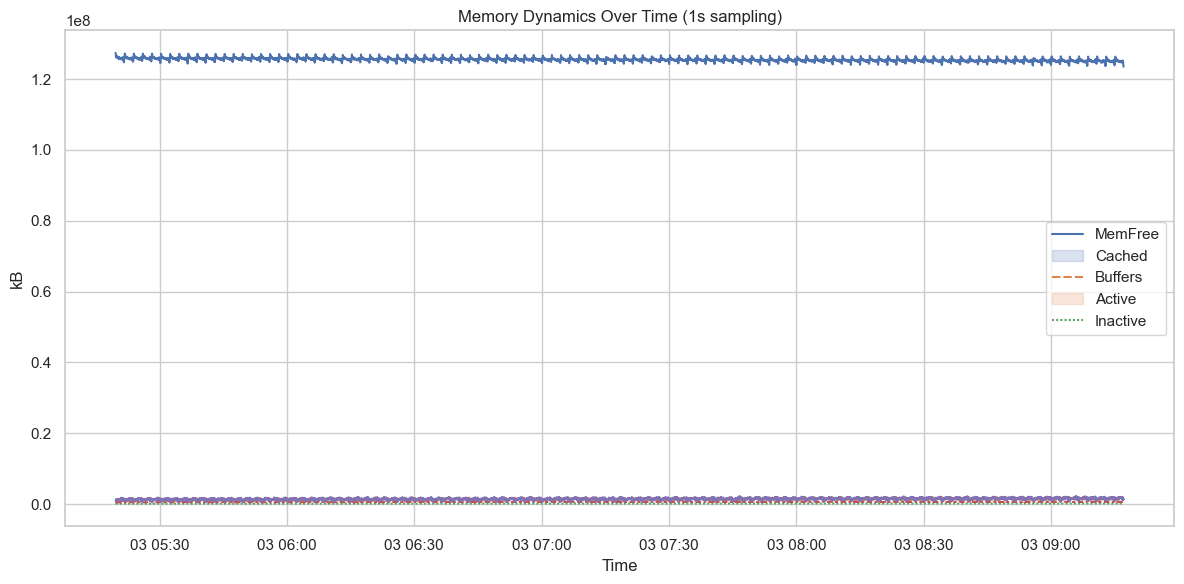

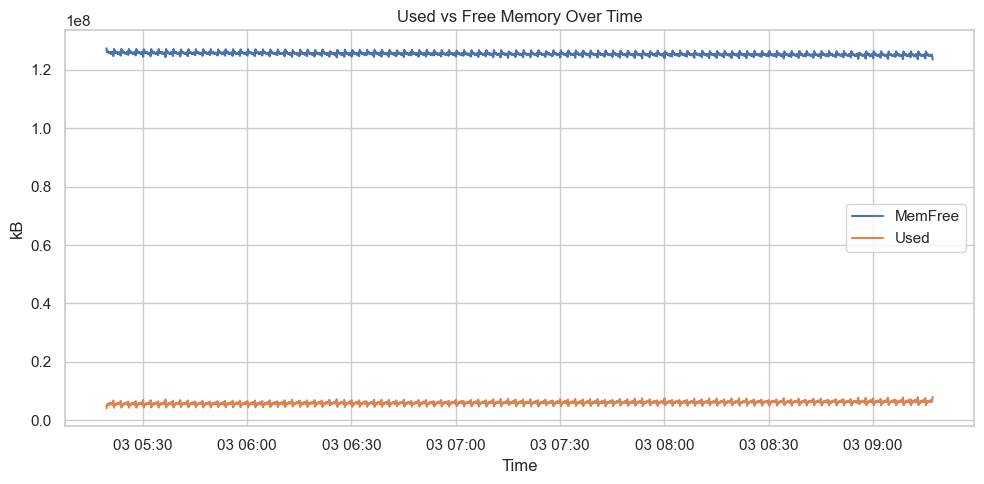

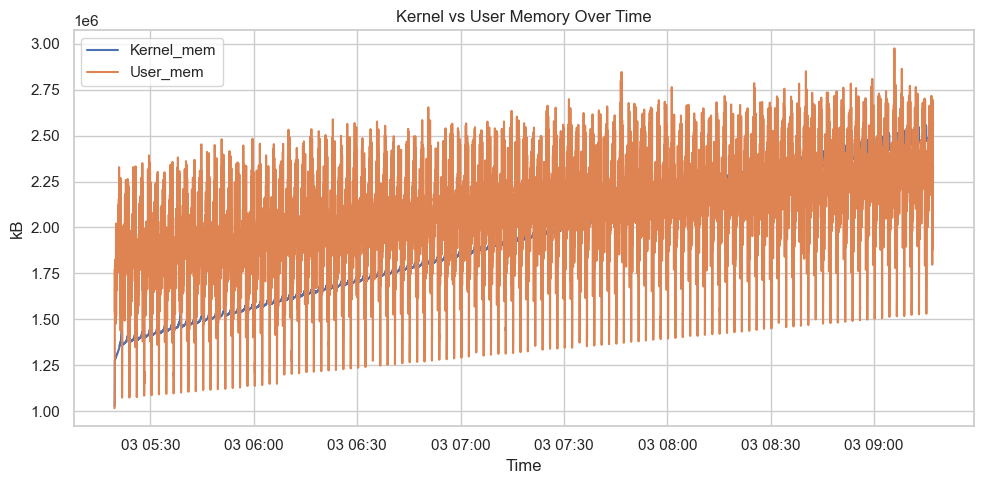

/Users/pabramov/dev/rtos_bench/src/plots.py:291: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stds.values, y=stds.index, palette="crest")


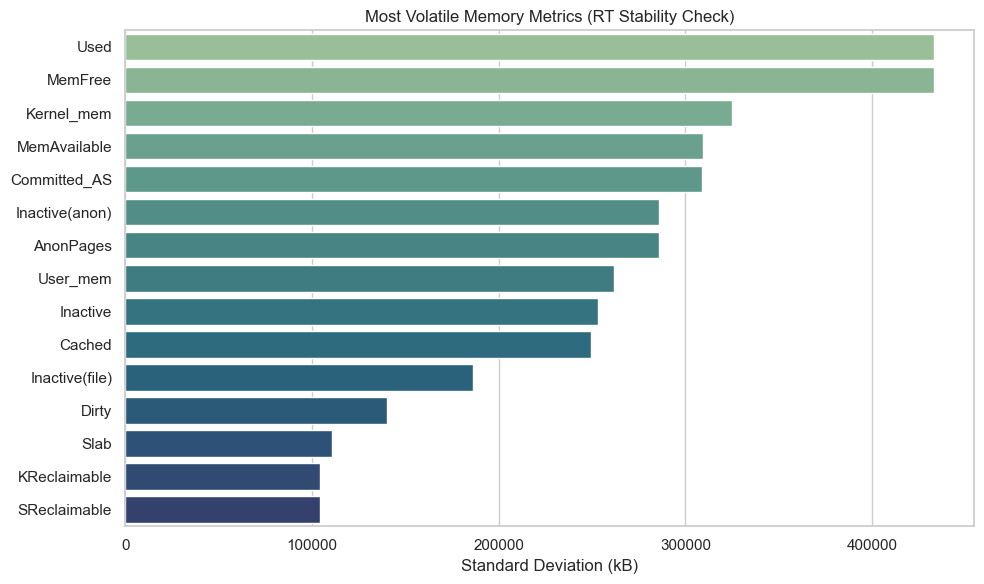

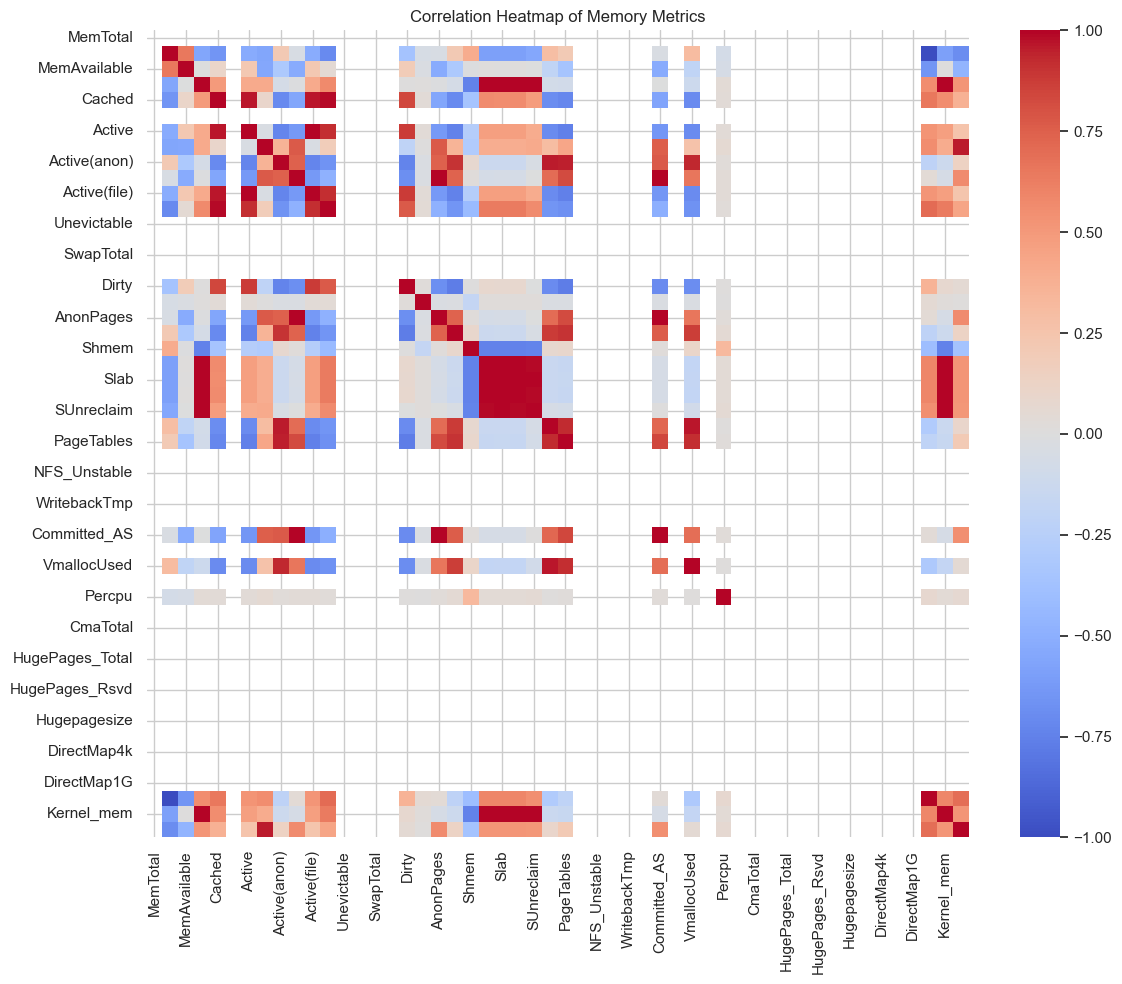

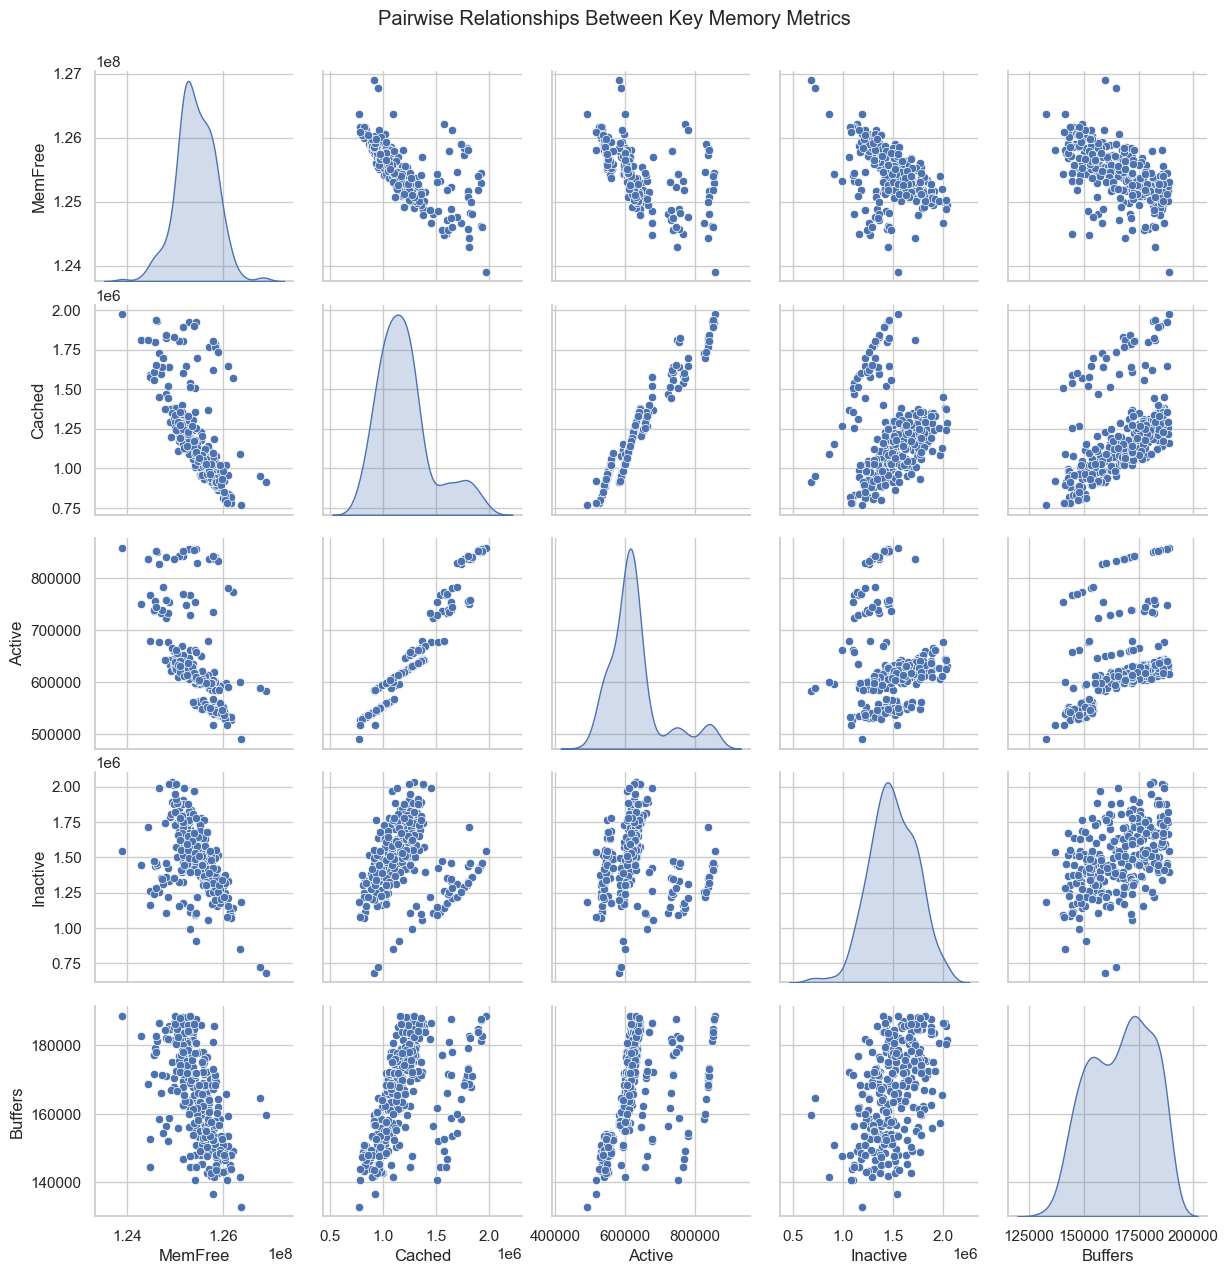

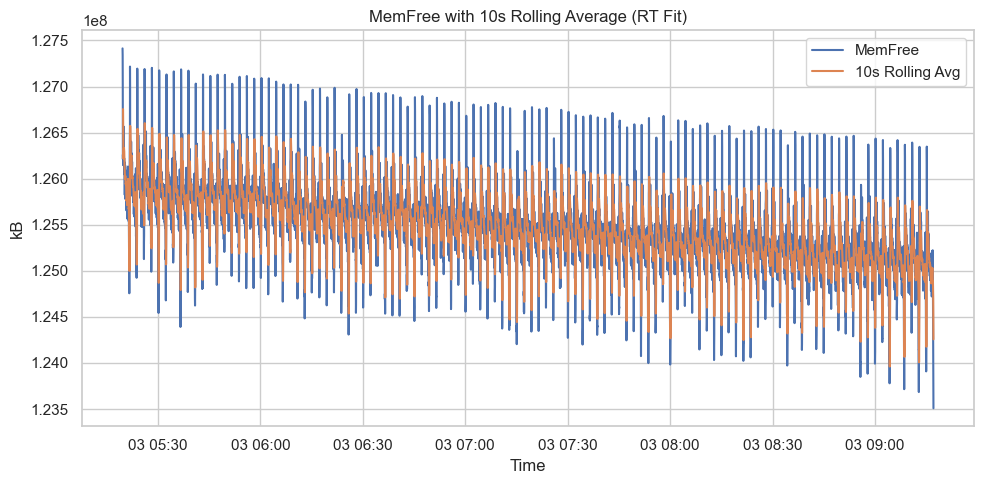

In [9]:
meminfo_monitor_df = pd.read_csv(meminfo_path)
plot_meminfo(meminfo_monitor_df)